# CFPB Credit-Card Complaints: Customer Experience & Issue Association Analysis

## Project Overview

This project uses natural language processing (NLP) and statistical association analysis to identify recurring customer-experience (CX) themes in CFPB credit-card complaints and determine which CFPB complaint issues are disproportionately associated with each theme.

**Methods:** text preprocessing → TF-IDF → NMF topic modeling → topic validation → complaint classification → chi-square test → Cramér's V → standardized Pearson residuals → business prioritization.


## 1. Business Objective

The objective is to convert large-scale unstructured complaint narratives into interpretable customer-experience themes and identify the complaint journeys where issues are most strongly concentrated.

The analysis focuses on two questions:

1. What recurring customer-experience themes appear in the complaint narratives?
2. Which CFPB complaint issues are disproportionately associated with those themes?


In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import NMF
from scipy.stats import chi2_contingency

# Load dataset
df = pd.read_csv("data_customer_analysis/complaints-2026-08-27_02_24.csv")

# Preserve the original narrative
df["narrative_raw"] = df["Consumer complaint narrative"]

# Basic text cleaning
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\bx+\b", " ", text)   # CFPB anonymization placeholders
    text = re.sub(r"[^a-z\s]", " ", text)  # keep alphabetic text
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["narrative_clean"] = df["narrative_raw"].apply(clean_text)

print(f"Total complaints loaded: {len(df):,}")
print(f"Missing complaint narratives: {df['narrative_raw'].isna().sum():,}")


Total complaints loaded: 94,618
Missing complaint narratives: 0


## 2. Data Preparation & Text Preprocessing

Duplicate complaint narratives are removed before topic modeling so that repeated text does not disproportionately influence the learned topics.

Company/product-specific terms and generic banking terms are also removed to make the topics more focused on the underlying customer experience rather than brand names or generic words.


In [5]:
# Keep one observation per unique cleaned narrative
df_nlp = df.drop_duplicates(
    subset=["narrative_clean"]
).copy()

print(f"Original complaints: {len(df):,}")
print(f"Unique narratives: {len(df_nlp):,}")
print(f"Removed duplicates: {len(df) - len(df_nlp):,}")

# Remove company/product-specific terms
company_terms = [
    "american express",
    "americanexpress",
    "amex",
    "wells fargo",
    "wells",
    "chase",
    "sapphire"
]

def remove_company_terms(text):
    for term in company_terms:
        text = text.replace(term, " ")
    return re.sub(r"\s+", " ", text).strip()

df["narrative_topic"] = df["narrative_clean"].apply(remove_company_terms)
df_nlp["narrative_topic"] = df_nlp["narrative_clean"].apply(remove_company_terms)

custom_stopwords = {
    "credit", "card", "account", "accounts", "bank",
    "company", "customer", "consumer",
    "american", "express", "amex", "wells", "fargo",
    "chase", "sapphire"
}

topic_noise = {
    "capital", "capital one", "called", "call", "told", "said",
    "phone", "email", "asked", "received", "sent", "letter",
    "got", "number"
}

final_stopwords = ENGLISH_STOP_WORDS.union(custom_stopwords).union(topic_noise)
print(f"Number of stopwords: {len(final_stopwords):,}")


Original complaints: 94,618
Unique narratives: 85,012
Removed duplicates: 9,606
Number of stopwords: 346


## 3. TF-IDF Representation

TF-IDF represents each complaint narrative numerically using unigram and bigram features. Terms that are common across documents receive less weight, while terms that are more informative for individual narratives receive more weight.


In [7]:
final_tfidf = TfidfVectorizer(
    stop_words=list(final_stopwords),
    ngram_range=(1, 2),
    min_df=10,
    max_df=0.90,
    max_features=10000
)

X_final = final_tfidf.fit_transform(df_nlp["narrative_topic"])
final_features = final_tfidf.get_feature_names_out()

print("Documents:", X_final.shape[0])
print("TF-IDF features:", X_final.shape[1])


Documents: 85012
TF-IDF features: 10000


## 4. NMF Topic Modeling & Topic Validation

Non-negative Matrix Factorization (NMF) is used to discover latent themes in the complaint narratives.

Candidate models with **4–10 topics** are compared using reconstruction error and topic diversity. The final model uses **6 topics**, selected as the most useful balance between model fit and interpretable, distinct customer-experience themes.


In [9]:
validation_results = []

for k in range(4, 11):
    nmf_test = NMF(
        n_components=k,
        random_state=42,
        init="nndsvda",
        max_iter=500
    )

    W_test = nmf_test.fit_transform(X_final)
    H_test = nmf_test.components_

    topic_words = []
    for topic in H_test:
        top_indices = topic.argsort()[-10:][::-1]
        topic_words.extend([final_features[i] for i in top_indices])

    topic_diversity = len(set(topic_words)) / len(topic_words)

    validation_results.append({
        "Topics": k,
        "Reconstruction Error": nmf_test.reconstruction_err_,
        "Topic Diversity": topic_diversity
    })

validation_df = pd.DataFrame(validation_results)
validation_df


,Topics,Reconstruction Error,Topic Diversity
0,4,284.520475,0.925000
1,5,283.830342,0.880000
2,6,283.241366,0.900000
3,7,282.650077,0.900000
4,8,282.068691,0.887500
5,9,281.466433,0.877778
6,10,280.914745,0.880000


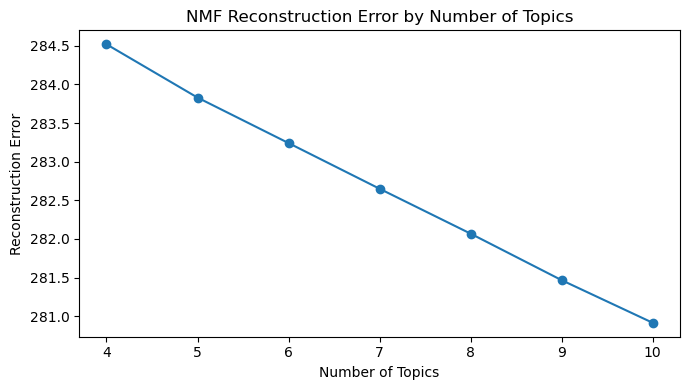

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(
    validation_df["Topics"],
    validation_df["Reconstruction Error"],
    marker="o"
)
plt.xlabel("Number of Topics")
plt.ylabel("Reconstruction Error")
plt.title("NMF Reconstruction Error by Number of Topics")
plt.xticks(validation_df["Topics"])
plt.tight_layout()
plt.savefig("nmf_reconstruction_error.png", dpi=300, bbox_inches="tight")
plt.show()


## 5. Final Six-Topic NMF Model

The final model contains six customer-experience themes.


In [12]:
FINAL_K = 6

nmf_final = NMF(
    n_components=FINAL_K,
    random_state=42,
    init="nndsvda",
    max_iter=500
)

W_final = nmf_final.fit_transform(X_final)
H_final = nmf_final.components_

print("Final number of topics:", FINAL_K)
print("Final reconstruction error:", nmf_final.reconstruction_err_)

for topic_idx, topic in enumerate(H_final):
    top_indices = topic.argsort()[-15:][::-1]
    top_words = [final_features[i] for i in top_indices]

    print(f"\nTOPIC {topic_idx + 1}")
    print(", ".join(top_words))


Final number of topics: 6
Final reconstruction error: 283.2413662270056

TOPIC 1
dispute, merchant, refund, charge, transaction, evidence, provided, year, pur, apple, return, documentation, case, claim, goldman

TOPIC 2
payment, late, payments, late payment, fee, fees, late fee, late fees, usc, paid, pay, remarks, payment remarks, time, balance

TOPIC 3
reporting, information, act, fcra, financial, fair, inaccurate, debt, provide, complaint, fair reporting, reporting act, request, federal, violation

TOPIC 4
report, identity, theft, identity theft, opened, fraudulent, information, open, fraud, victim, police, victim identity, knowledge, inquiry, police report

TOPIC 5
charges, fraud, fraudulent, transactions, unauthorized, fraudulent charges, charge, did, claim, america, new, unauthorized charges, investigation, transaction, pur

TOPIC 6
balance, citi, pay, closed, paid, offer, transfer, points, year, time, money, fee, did, pur, cards


## 6. Complaint Classification & CX Theme Labels


In [14]:
# Assign each unique narrative to its dominant NMF topic
row_sums = W_final.sum(axis=1)

valid_nmf_mask = row_sums > 0
W_valid = W_final[valid_nmf_mask]

W_normalized_valid = W_valid / W_valid.sum(axis=1, keepdims=True)

df_nlp_valid = df_nlp.loc[valid_nmf_mask].copy()

df_nlp_valid["dominant_topic"] = (
    W_normalized_valid.argmax(axis=1) + 1
)

df_nlp_valid["topic_confidence"] = (
    W_normalized_valid.max(axis=1)
)

topic_names = {
    1: "Merchant Disputes & Refunds",
    2: "Payment & Late-Fee Issues",
    3: "Credit Reporting & Inaccurate Information",
    4: "Identity Theft & Fraudulent Accounts",
    5: "Fraud & Unauthorized Transactions",
    6: "Balance Transfers & Promotional Offers"
}

df_nlp_valid["CX_Theme"] = (
    df_nlp_valid["dominant_topic"].map(topic_names)
)

print("Total NMF observations:", len(W_final))
print("Valid NMF observations:", len(df_nlp_valid))
print("Excluded zero-topic observations:", (~valid_nmf_mask).sum())
print("\nCX theme distribution:")
print(df_nlp_valid["CX_Theme"].value_counts())


Total NMF observations: 85012
Valid NMF observations: 84999
Excluded zero-topic observations: 13

CX theme distribution:
CX_Theme
Balance Transfers & Promotional Offers       29689
Merchant Disputes & Refunds                  12862
Payment & Late-Fee Issues                    12151
Credit Reporting & Inaccurate Information    11461
Fraud & Unauthorized Transactions             9635
Identity Theft & Fraudulent Accounts          9201
Name: count, dtype: int64


In [15]:
theme_summary = (
    df_nlp_valid
    .groupby("CX_Theme")
    .agg(
        Complaints=("CX_Theme", "size"),
        Avg_Topic_Confidence=("topic_confidence", "mean")
    )
    .sort_values("Complaints", ascending=False)
)

theme_summary["Complaint Share %"] = (
    theme_summary["Complaints"]
    / theme_summary["Complaints"].sum()
    * 100
)

theme_summary.round({
    "Avg_Topic_Confidence": 3,
    "Complaint Share %": 2
})


,Complaints,Avg_Topic_Confidence,Complaint Share %
CX_Theme,,,
Balance Transfers & Promotional Offers,29689,0.630,34.93
Merchant Disputes & Refunds,12862,0.618,15.13
Payment & Late-Fee Issues,12151,0.617,14.30
Credit Reporting & Inaccurate Information,11461,0.603,13.48
Fraud & Unauthorized Transactions,9635,0.565,11.34
Identity Theft & Fraudulent Accounts,9201,0.627,10.82


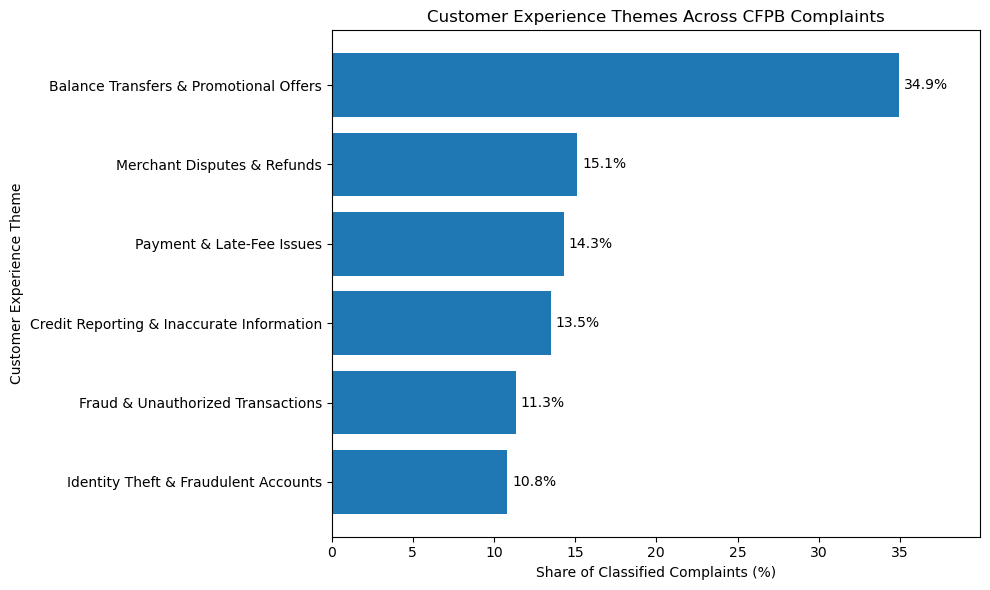

In [16]:
plot_data = theme_summary.sort_values(
    "Complaints",
    ascending=True
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_data.index,
    plot_data["Complaint Share %"]
)

for bar, value in zip(bars, plot_data["Complaint Share %"]):
    plt.text(
        value + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center"
    )

plt.xlabel("Share of Classified Complaints (%)")
plt.ylabel("Customer Experience Theme")
plt.title("Customer Experience Themes Across CFPB Complaints")
plt.xlim(0, plot_data["Complaint Share %"].max() + 5)
plt.tight_layout()
plt.savefig("customer_experience_themes.png", dpi=300, bbox_inches="tight")
plt.show()


## 7. CX Theme × CFPB Issue Association Analysis

A contingency table is constructed between the six NLP-derived CX themes and CFPB complaint issues.

A chi-square test evaluates whether the two categorical variables are statistically independent. Cramér's V measures the strength of the overall association.

Standardized Pearson residuals then identify **which specific CX theme × CFPB issue pairs occur more often than expected**.


In [18]:
contingency = pd.crosstab(
    df_nlp_valid["CX_Theme"],
    df_nlp_valid["Issue"]
)

print("Contingency table shape:", contingency.shape)
print("Total observations:", contingency.values.sum())
display(contingency)


Contingency table shape: (6, 15)
Total observations: 84999


Issue,"Advertising and marketing, including promotional offers",Closing your account,Credit monitoring or identity theft protection services,Fees or interest,Getting a credit card,Improper use of your report,Incorrect information on your report,"Other features, terms, or problems",Problem when making payments,Problem with a company's investigation into an existing problem,Problem with a purchase shown on your statement,Problem with fraud alerts or security freezes,Struggling to pay your bill,Trouble using your card,Unable to get your credit report or credit score
CX_Theme,,,,,,,,,,,,,,,
Balance Transfers & Promotional Offers,3548,3563,58,4159,2443,67,304,7065,1535,225,3867,22,430,2386,17
Credit Reporting & Inaccurate Information,236,1520,29,698,1857,360,1595,1534,551,899,1135,16,315,704,12
Fraud & Unauthorized Transactions,67,282,13,575,289,6,45,539,68,70,7446,14,17,203,1
Identity Theft & Fraudulent Accounts,119,542,112,62,4879,316,860,610,51,294,1093,50,27,177,9
Merchant Disputes & Refunds,118,92,2,127,84,4,25,777,46,33,11468,0,5,81,0
Payment & Late-Fee Issues,147,840,19,3078,112,40,1234,795,2688,1584,706,4,376,524,4


In [19]:
chi2_stat, p_value, dof, expected = chi2_contingency(
    contingency
)

n = contingency.values.sum()
r, k = contingency.shape

cramers_v = np.sqrt(
    chi2_stat / (n * min(r - 1, k - 1))
)

print("Chi-square statistic:", round(chi2_stat, 2))
print("Degrees of freedom:", dof)
print("p-value:", p_value)
print("Cramér's V:", round(cramers_v, 3))


Chi-square statistic: 84742.42
Degrees of freedom: 70
p-value: 0.0
Cramér's V: 0.447


In [20]:
expected_df = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)

residuals = (
    contingency - expected_df
) / np.sqrt(expected_df)

residual_long = (
    residuals
    .stack()
    .reset_index()
)

residual_long.columns = [
    "CX Theme",
    "CFPB Issue",
    "Standardized Residual"
]

residual_long = residual_long.sort_values(
    "Standardized Residual",
    ascending=False
)

print("Strongest positive associations:")
display(residual_long.head(15))

print("Minimum expected frequency:", expected.min())
print("Cells with expected frequency < 5:", (expected < 5).sum())


Strongest positive associations:


,CX Theme,CFPB Issue,Standardized Residual
70,Merchant Disputes & Refunds,Problem with a purchase shown on your statement,121.463674
49,Identity Theft & Fraudulent Accounts,Getting a credit card,118.505109
40,Fraud & Unauthorized Transactions,Problem with a purchase shown on your statement,83.924920
83,Payment & Late-Fee Issues,Problem when making payments,74.588770
84,Payment & Late-Fee Issues,Problem with a company's investigation into an...,54.115653
0,Balance Transfers & Promotional Offers,"Advertising and marketing, including promotion...",53.789191
78,Payment & Late-Fee Issues,Fees or interest,52.019863
7,Balance Transfers & Promotional Offers,"Other features, terms, or problems",49.476242
21,Credit Reporting & Inaccurate Information,Incorrect information on your report,44.738802
81,Payment & Late-Fee Issues,Incorrect information on your report,27.102371


Minimum expected frequency: 4.654678290332828
Cells with expected frequency < 5: 2


## 8. Strongest CX × CFPB Issue Associations


In [22]:
association_results = []

for i, cx_theme in enumerate(contingency.index):
    for j, cfpb_issue in enumerate(contingency.columns):

        observed = contingency.iloc[i, j]
        expected_value = expected[i, j]
        residual = (
            observed - expected_value
        ) / np.sqrt(expected_value)

        if residual >= 50:
            strength = "Very Strong"
        elif residual >= 25:
            strength = "Strong"
        elif residual >= 15:
            strength = "Moderate"
        else:
            strength = "Weak"

        association_results.append({
            "CX Theme": cx_theme,
            "CFPB Issue": cfpb_issue,
            "Observed Cases": observed,
            "Expected Cases": expected_value,
            "Standardized Residual": residual,
            "Association Strength": strength
        })

association_results = (
    pd.DataFrame(association_results)
    .sort_values("Standardized Residual", ascending=False)
    .reset_index(drop=True)
)

display(
    association_results.head(15).round({
        "Expected Cases": 2,
        "Standardized Residual": 2
    })
)


,CX Theme,CFPB Issue,Observed Cases,Expected Cases,Standardized Residual,Association Strength
0,Merchant Disputes & Refunds,Problem with a purchase shown on your statement,11468,3891.18,121.46,Very Strong
1,Identity Theft & Fraudulent Accounts,Getting a credit card,4879,1046.11,118.51,Very Strong
2,Fraud & Unauthorized Transactions,Problem with a purchase shown on your statement,7446,2914.91,83.92,Very Strong
3,Payment & Late-Fee Issues,Problem when making payments,2688,706.05,74.59,Very Strong
4,Payment & Late-Fee Issues,Problem with a company's investigation into an...,1584,443.87,54.12,Very Strong
5,Balance Transfers & Promotional Offers,"Advertising and marketing, including promotion...",3548,1479.23,53.79,Very Strong
6,Payment & Late-Fee Issues,Fees or interest,3078,1243.56,52.02,Very Strong
7,Balance Transfers & Promotional Offers,"Other features, terms, or problems",7065,3953.92,49.48,Strong
8,Credit Reporting & Inaccurate Information,Incorrect information on your report,1595,547.84,44.74,Strong
9,Payment & Late-Fee Issues,Incorrect information on your report,1234,580.82,27.10,Strong


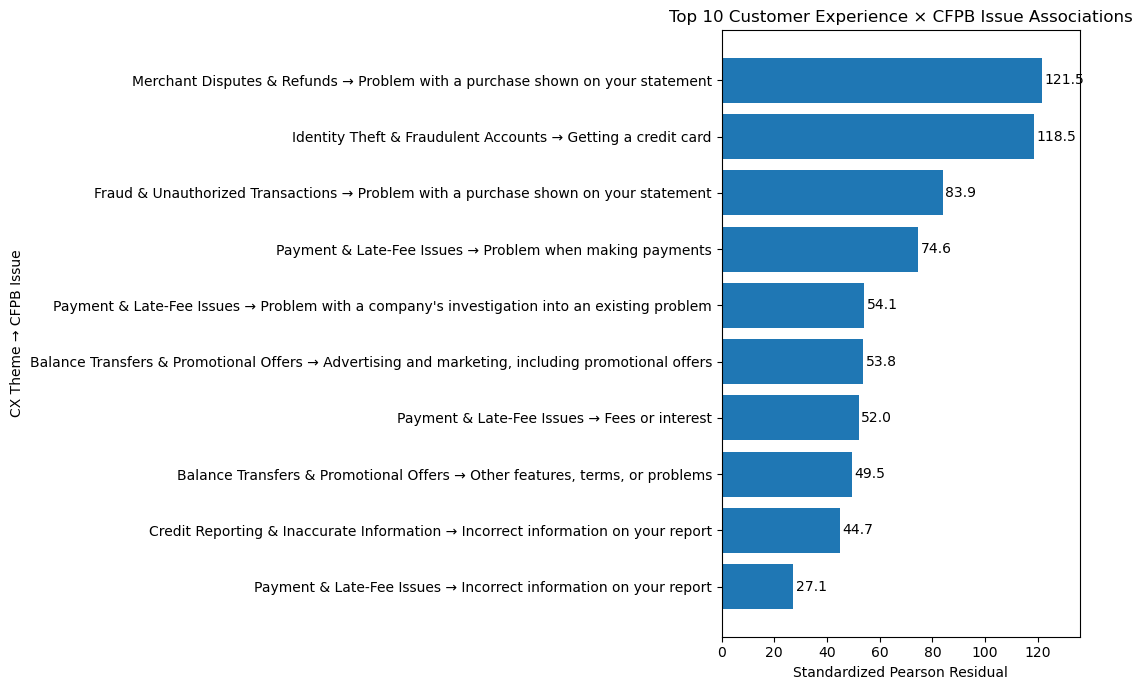

In [23]:
top_10 = association_results.head(10).copy()

top_10["Association"] = (
    top_10["CX Theme"]
    + " → "
    + top_10["CFPB Issue"]
)

top_10 = top_10.sort_values(
    "Standardized Residual",
    ascending=True
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    top_10["Association"],
    top_10["Standardized Residual"]
)

for bar, value in zip(
    bars,
    top_10["Standardized Residual"]
):
    plt.text(
        value + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        va="center"
    )

plt.title("Top 10 Customer Experience × CFPB Issue Associations")
plt.xlabel("Standardized Pearson Residual")
plt.ylabel("CX Theme → CFPB Issue")
plt.xlim(0, top_10["Standardized Residual"].max() * 1.12)
plt.tight_layout()
plt.savefig("top_cx_cfpb_associations.png", dpi=300, bbox_inches="tight")
plt.show()


## 9. Business Priority Matrix

Complaint volume alone does not show where customer-experience problems are disproportionately concentrated.

The matrix combines:

- **Observed complaint volume** on the x-axis
- **Association strength** (standardized Pearson residual) on the y-axis
- Median values as practical thresholds

The **high-volume + high-association quadrant** identifies the strongest candidates for business intervention.


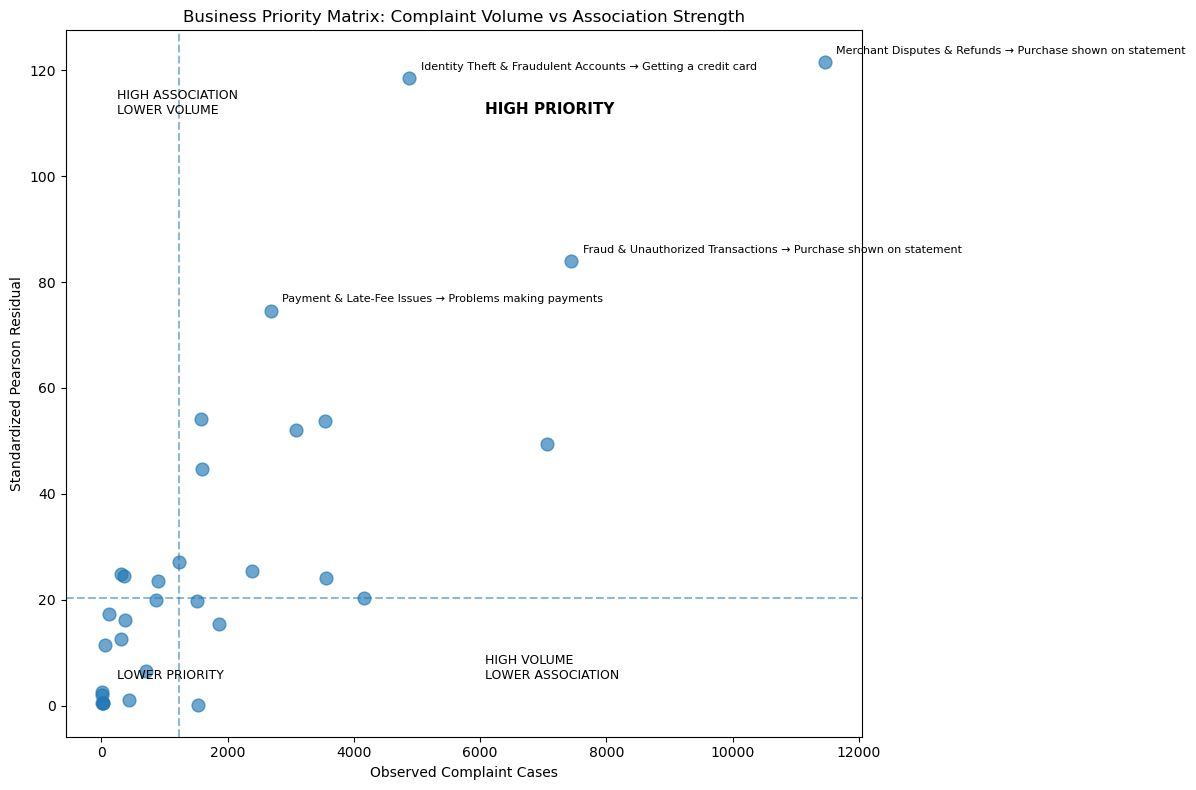

Priority thresholds
Median complaint volume: 1234
Median association strength: 20.33


In [25]:
priority_df = association_results[
    association_results["Standardized Residual"] > 0
].copy()

volume_threshold = priority_df["Observed Cases"].median()
association_threshold = priority_df["Standardized Residual"].median()

plt.figure(figsize=(12, 8))

plt.scatter(
    priority_df["Observed Cases"],
    priority_df["Standardized Residual"],
    s=85,
    alpha=0.65
)

top_4 = priority_df.nlargest(
    4,
    "Standardized Residual"
)

for _, row in top_4.iterrows():

    issue = row["CFPB Issue"]

    if "purchase shown on your statement" in issue:
        issue_short = "Purchase shown on statement"
    elif "Getting a credit card" in issue:
        issue_short = "Getting a credit card"
    elif "making payments" in issue:
        issue_short = "Problems making payments"
    else:
        issue_short = issue[:35]

    label = f"{row['CX Theme']} → {issue_short}"

    plt.annotate(
        label,
        (row["Observed Cases"], row["Standardized Residual"]),
        xytext=(8, 6),
        textcoords="offset points",
        fontsize=8
    )

plt.axvline(
    volume_threshold,
    linestyle="--",
    alpha=0.5
)

plt.axhline(
    association_threshold,
    linestyle="--",
    alpha=0.5
)

x_min = priority_df["Observed Cases"].min()
x_max = priority_df["Observed Cases"].max()
y_min = priority_df["Standardized Residual"].min()
y_max = priority_df["Standardized Residual"].max()

plt.text(
    x_min + (x_max - x_min) * 0.53,
    y_max * 0.92,
    "HIGH PRIORITY",
    fontsize=11,
    fontweight="bold"
)

plt.text(
    x_min + (x_max - x_min) * 0.02,
    y_max * 0.92,
    "HIGH ASSOCIATION\nLOWER VOLUME",
    fontsize=9
)

plt.text(
    x_min + (x_max - x_min) * 0.53,
    y_min + (y_max - y_min) * 0.04,
    "HIGH VOLUME\nLOWER ASSOCIATION",
    fontsize=9
)

plt.text(
    x_min + (x_max - x_min) * 0.02,
    y_min + (y_max - y_min) * 0.04,
    "LOWER PRIORITY",
    fontsize=9
)

plt.title("Business Priority Matrix: Complaint Volume vs Association Strength")
plt.xlabel("Observed Complaint Cases")
plt.ylabel("Standardized Pearson Residual")
plt.tight_layout()
plt.savefig("business_priority_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print("Priority thresholds")
print(f"Median complaint volume: {volume_threshold:.0f}")
print(f"Median association strength: {association_threshold:.2f}")


In [26]:
high_priority = priority_df[
    (priority_df["Observed Cases"] >= volume_threshold) &
    (priority_df["Standardized Residual"] >= association_threshold)
].copy()

high_priority = (
    high_priority
    .sort_values("Standardized Residual", ascending=False)
    .reset_index(drop=True)
)

business_priority_table = high_priority[
    [
        "CX Theme",
        "CFPB Issue",
        "Observed Cases",
        "Expected Cases",
        "Standardized Residual",
        "Association Strength"
    ]
].copy()

display(
    business_priority_table.round({
        "Expected Cases": 2,
        "Standardized Residual": 2
    })
)


,CX Theme,CFPB Issue,Observed Cases,Expected Cases,Standardized Residual,Association Strength
0,Merchant Disputes & Refunds,Problem with a purchase shown on your statement,11468,3891.18,121.46,Very Strong
1,Identity Theft & Fraudulent Accounts,Getting a credit card,4879,1046.11,118.51,Very Strong
2,Fraud & Unauthorized Transactions,Problem with a purchase shown on your statement,7446,2914.91,83.92,Very Strong
3,Payment & Late-Fee Issues,Problem when making payments,2688,706.05,74.59,Very Strong
4,Payment & Late-Fee Issues,Problem with a company's investigation into an...,1584,443.87,54.12,Very Strong
5,Balance Transfers & Promotional Offers,"Advertising and marketing, including promotion...",3548,1479.23,53.79,Very Strong
6,Payment & Late-Fee Issues,Fees or interest,3078,1243.56,52.02,Very Strong
7,Balance Transfers & Promotional Offers,"Other features, terms, or problems",7065,3953.92,49.48,Strong
8,Credit Reporting & Inaccurate Information,Incorrect information on your report,1595,547.84,44.74,Strong
9,Payment & Late-Fee Issues,Incorrect information on your report,1234,580.82,27.10,Strong


## 10. Business Recommendations

The recommendations below translate the strongest statistical relationships into practical customer-experience priorities.


In [28]:
recommendations = pd.DataFrame({
    "Priority": [1, 2, 3, 4, 5],

    "Key Finding": [
        "Merchant disputes are strongly concentrated around purchases appearing on customer statements.",
        "Identity theft and fraudulent-account complaints are strongly associated with obtaining a credit card.",
        "Fraud and unauthorized-transaction complaints are strongly associated with disputed purchases appearing on statements.",
        "Payment and late-fee complaints are strongly concentrated around problems making payments.",
        "Balance-transfer and promotional-offer complaints are strongly associated with advertising, promotional terms, and product features."
    ],

    "Business Recommendation": [
        "Improve merchant-dispute and refund workflows, with clearer transaction investigation status and faster resolution.",
        "Strengthen identity verification and account-opening controls, while improving support for customers reporting potentially fraudulent applications.",
        "Enhance transaction monitoring and dispute workflows for potentially unauthorized purchases, with clearer customer communication.",
        "Improve payment-status visibility, exception handling, and resolution processes for payment failures and related fees.",
        "Review promotional-offer communication and make balance-transfer eligibility, fees, terms, and conditions easier for customers to understand."
    ]
})

display(recommendations)


,Priority,Key Finding,Business Recommendation
0,1,Merchant disputes are strongly concentrated ar...,"Improve merchant-dispute and refund workflows,..."
1,2,Identity theft and fraudulent-account complain...,Strengthen identity verification and account-o...
2,3,Fraud and unauthorized-transaction complaints ...,Enhance transaction monitoring and dispute wor...
3,4,Payment and late-fee complaints are strongly c...,"Improve payment-status visibility, exception h..."
4,5,Balance-transfer and promotional-offer complai...,Review promotional-offer communication and mak...


# Executive Summary

## Objective

This project analyzes CFPB credit-card complaints to identify recurring customer-experience themes and determine which complaint issues are most strongly associated with each theme. The analysis combines natural language processing with statistical association analysis to translate unstructured customer complaints into actionable business insights.

## Key Findings

- **84,999 valid complaints** were analyzed after excluding observations without a valid NMF topic representation.
- **6 customer-experience (CX) themes** were identified using TF-IDF and Non-negative Matrix Factorization (NMF).
- **Balance Transfers & Promotional Offers** was the largest CX theme, accounting for **34.9%** of classified complaints.
- A chi-square test confirmed a statistically significant association between CX themes and CFPB complaint issues (**χ² = 84,742.42, p < 0.001**).
- The overall association had a **Cramér's V of 0.447**, indicating a substantial relationship between the two categorical variables.
- Standardized Pearson residuals identified several particularly strong CX × CFPB issue relationships.

## Strongest Associations

The strongest observed relationship was between **Merchant Disputes & Refunds** and **problems with purchases shown on customer statements**, with **11,468 observed cases compared with approximately 3,892 expected cases**.

Other highly concentrated relationships included:

- **Identity Theft & Fraudulent Accounts → Getting a credit card:** 4,879 observed vs. 1,046 expected cases.
- **Fraud & Unauthorized Transactions → Problems with purchases shown on statements:** 7,446 observed vs. 2,915 expected cases.
- **Payment & Late-Fee Issues → Problems making payments:** 2,688 observed vs. 706 expected cases.

## Business Implications

The findings suggest that complaint volume alone is insufficient for prioritizing customer-experience improvements. Combining complaint volume with statistical association strength helps identify specific customer journeys where complaints are disproportionately concentrated.

The analysis points to opportunities to improve **merchant-dispute and refund workflows, identity verification and account-opening controls, unauthorized-transaction handling, payment-processing transparency, and promotional-offer communication**.

Overall, the project demonstrates how **NLP-based topic modeling and statistical analysis can convert large-scale unstructured complaint data into interpretable customer-experience insights and actionable business priorities.**
